# Lindsay Foster Notebook
# Intro to Web Mining & Applied NLP


- Author: [Lindsay Foster](https://github.com/LFoster03)
- Repository: [nlp-01-getting-started](https://github.com/LFoster03/nlp-01-getting-started)
- Purpose: Demonstrate web mining and applied natural language processing (NLP)
- Date: March 10, 2026

# Notebook Modifications

This notebook is based on the original **web_words_case** example script, with the following modifications and enhancements applied:

---

## Data Source
- All text is retrieved from a web page rather than a local file.
- The webpage URL is stored in the variable `url`.
- No CSV input is required; the frequency tables and word cloud are generated directly from the webpage text.

---

## Text Processing Enhancements
1. **Lowercasing** – All words are converted to lowercase for consistent counting.
2. **Punctuation Removal** – Leading and trailing punctuation is stripped from each token.
3. **Stopword Filtering** – Common words that provide little analytic value are removed.
4. **Token Length Filtering** – Words with ≤3 characters are excluded to reduce noise.
5. **Average Word Length** – Computed across all cleaned tokens for exploratory insight.

---

## Frequency Analysis
- A **Polars DataFrame** is created to count word occurrences.
- Words are grouped, counted, and sorted from most to least frequent.
- Top 20 frequent words are displayed for inspection.

---

## Visualizations
1. **Bar Chart** – Top 10 most frequent words are plotted.
2. **Word Cloud** – Visual representation of word frequencies, with larger words representing higher frequency.

---

## Notes
- All outputs reflect the **cleaned and filtered word set**.
- The notebook provides interactive, reproducible analysis of webpage text.
- Modifications are designed to enhance **observability** and **analytical insight** over the base example.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

In [13]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import polars as pl
import requests
from wordcloud import WordCloud

print("Imports complete.")

Imports complete.


## Section 2. Retrieve a Web Page (as HTML text)

This is a Markdown cell.

In [14]:
# Section 2 Python cell

# Choose a page to analyze.
# The Shakespeare page is simple and stable.
# The Wikipedia page is interesting, but requires a User-Agent header.
# url: str = "https://shakespeare.mit.edu/romeo_juliet/full.html"
url: str = "https://en.wikipedia.org/wiki/Natural_language_processing"

# Some sites reject requests that look like anonymous scripts.
# This header helps the request look more like a normal browser visit.
headers: dict[str, str] = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Course-Example/1.0)"
}

# Request the page and stop with an error if the request fails.
response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

# Store the raw HTML text.
html: str = response.text

print(f"Downloaded {len(html):,} characters from:")
print(url)

Downloaded 322,711 characters from:
https://en.wikipedia.org/wiki/Natural_language_processing


## Section 3. Parse the HTML (into a BeautifulSoup tree)

This is a Markdown cell.

In [15]:
# Section 3 Python cell

# BeautifulSoup() takes raw HTML text
# and builds a parse tree (a structured representation of the document)
# we assign to a variable named soup (short for "soup of tags").

# Example Input:
# "<html><body><p>Hello</p></body></html>"

# Example BeautifulSoup parse tree:
# html
#  └── body
#       └── p
#            └── "Hello"

# This makes it easier to extract text and inspect page structure.

# Call BeautifulSoup with the raw HTML and a parser (lxml is fast and lenient).
soup: BeautifulSoup = BeautifulSoup(html, "lxml")

print("HTML parsed successfully.")
print(type(soup))

HTML parsed successfully.
<class 'bs4.BeautifulSoup'>


## Section 4. Extract Visible Text from the HTML

This is a Markdown cell.

In [16]:
# Section 4 Python cell

# Extract visible text from the page with get_text() method.
# separator=" " inserts spaces between chunks of text.
# strip=True removes leading and trailing whitespace.
text: str = soup.get_text(separator=" ", strip=True)

# Use [0:1000] to show only the first 1000 characters of the text.
# Or [:1000] gives the same result, since the start index defaults to 0.
print("First 1000 characters of extracted text:")
print(text[:1000])

First 1000 characters of extracted text:
Natural language processing - Wikipedia Jump to content Main menu Main menu move to sidebar hide Navigation Main page Contents Current events Random article About Wikipedia Contact us Contribute Help Learn to edit Community portal Recent changes Upload file Special pages Search Search Appearance Donate Create account Log in Personal tools Donate Create account Log in Contents move to sidebar hide (Top) 1 History Toggle History subsection 1.1 Symbolic NLP (1950s – early 1990s) 1.2 Statistical NLP (1990s–present) 2 Approaches: Symbolic, statistical, neural networks Toggle Approaches: Symbolic, statistical, neural networks subsection 2.1 Statistical approach 2.2 Neural networks 3 Common NLP tasks Toggle Common NLP tasks subsection 3.1 Text and speech processing 3.2 Morphological analysis 3.3 Syntactic analysis 3.4 Lexical semantics (of individual words in context) 3.5 Relational semantics (semantics of individual sentences) 3.6 Discourse (semantics

## Section 5. Clean the Text (split, lowercase, remove punctuation)

This is a Markdown cell.

In [17]:
# Section 5: Clean the Text and Compute Average Word Length

# Split text into words
words = text.split()

# Print first 20 words and total
print("First 20 raw words:", words[:20])
print("Total raw words:", len(words))

# Convert to lowercase
words = [w.lower() for w in words]

# Define stopwords
STOPWORDS = {
    "this",
    "that",
    "with",
    "from",
    "have",
    "were",
    "been",
    "their",
    "they",
    "them",
    "then",
    "than",
    "into",
    "also",
    "such",
    "only",
    "about",
    "over",
    "some",
    "many",
    "most",
    "other",
    "more",
}

# Remove punctuation, short tokens, and stopwords
clean_words = [
    w.strip(".,:;!?()[]\"'") for w in words if len(w) > 3 and w not in STOPWORDS
]

print("First 20 cleaned words:", clean_words[:20])
print("Total cleaned words:", len(clean_words))

# Compute average word length
avg_word_length = sum(len(w) for w in clean_words) / len(clean_words)
print(f"Average word length: {avg_word_length:.2f} characters")

First 20 raw words: ['Natural', 'language', 'processing', '-', 'Wikipedia', 'Jump', 'to', 'content', 'Main', 'menu', 'Main', 'menu', 'move', 'to', 'sidebar', 'hide', 'Navigation', 'Main', 'page', 'Contents']
Total raw words: 8217
First 20 cleaned words: ['natural', 'language', 'processing', 'wikipedia', 'jump', 'content', 'main', 'menu', 'main', 'menu', 'move', 'sidebar', 'hide', 'navigation', 'main', 'page', 'contents', 'current', 'events', 'random']
Total cleaned words: 5097
Average word length: 7.54 characters


## Section 6. Build a Frequency Table (Polars)


This is a Markdown cell.

In [18]:
# Section 6: Build Frequency Table and Optional CSV Output

# Create Polars DataFrame
df: pl.DataFrame = pl.DataFrame({"word": clean_words})

# Group by word, count occurrences, sort descending
freq_df: pl.DataFrame = df.group_by("word").len().sort("len", descending=True)

# Display top 20 words
print("Top 20 most frequent words:")
print(freq_df.head(20))

# Data source note
print(f"(Data source: web page at {url})")

Top 20 most frequent words:
shape: (20, 2)
┌────────────┬─────┐
│ word       ┆ len │
│ ---        ┆ --- │
│ str        ┆ u64 │
╞════════════╪═════╡
│ language   ┆ 110 │
│ natural    ┆ 69  │
│ processing ┆ 54  │
│ text       ┆ 51  │
│ e.g        ┆ 35  │
│ …          ┆ …   │
│ machine    ┆ 23  │
│ neural     ┆ 23  │
│ analysis   ┆ 22  │
│ data       ┆ 21  │
│ word       ┆ 21  │
└────────────┴─────┘
(Data source: web page at https://en.wikipedia.org/wiki/Natural_language_processing)


## Section 7. Build "Most Frequent Words" Bar Chart

This is a Markdown cell.

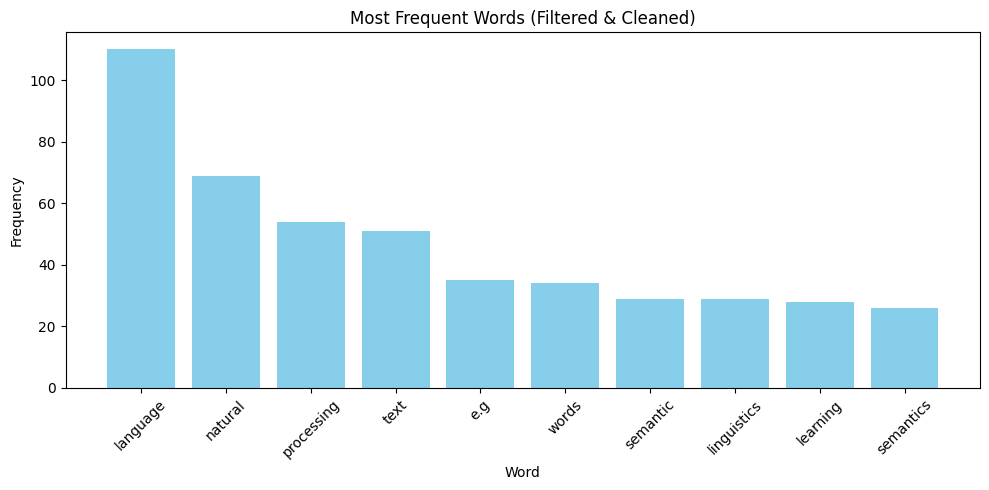

(Data source: web page at https://en.wikipedia.org/wiki/Natural_language_processing)


In [19]:
# Section 7: Bar Chart of Top 10 Most Frequent Words

top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["word"], top_df["len"], color="skyblue")

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Words (Filtered & Cleaned)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"(Data source: web page at {url})")

## Section 8. Build a Word Cloud

This is a Markdown cell.

Sample of word frequencies (top 10):
language: 110
natural: 69
processing: 54
text: 51
e.g: 35
words: 34
semantic: 29
linguistics: 29
learning: 28
semantics: 26


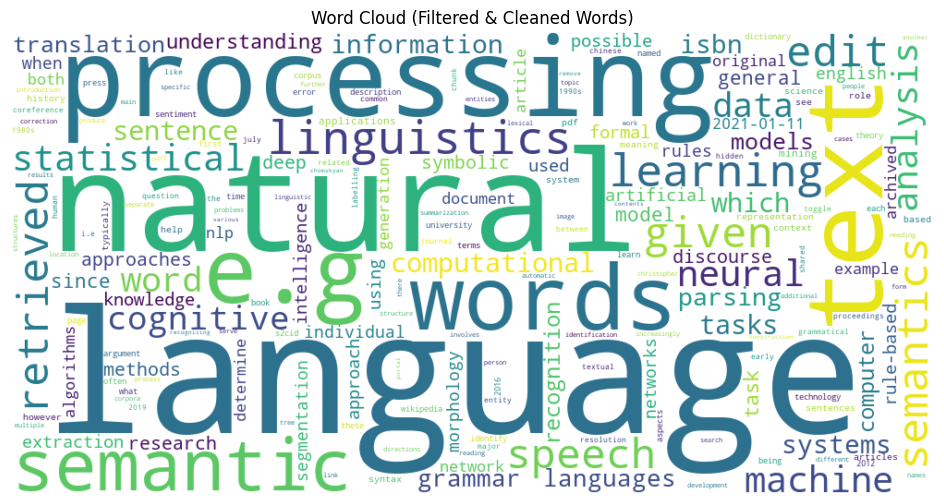

(Data source: web page at https://en.wikipedia.org/wiki/Natural_language_processing)


In [20]:
# Section 8: Word Cloud from Cleaned & Filtered Words

# Convert frequency table to dictionary
freq_dict: dict[str, int] = dict(
    zip(freq_df["word"].to_list(), freq_df["len"].to_list(), strict=True)
)

# Print top 10 frequencies
print("Sample of word frequencies (top 10):")
for word, freq in list(freq_dict.items())[:10]:
    print(f"{word}: {freq}")

# Build WordCloud
wc: WordCloud = WordCloud(width=1000, height=500, background_color="white")
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Filtered & Cleaned Words)")
plt.show()

print(f"(Data source: web page at {url})")

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
